# Proyecto: Impacto de la Inteligencia Artificial en el Empleo (Hacia 2030)

**Asignatura:** MCDI500 — Programación para la Ciencia de Datos  
**Fase:** 4 — Sumativa 4: Integración, Análisis y Comunicación de Resultados  
**Autores:** Arturo Knopke · Nicolás Soletic · Roberto Moncada · Sebastián Navarrete  
**Fecha:** 2026-06-16

---

## Propósito de este notebook (Fase 4)

Este notebook es el integrador final del proyecto ABP. Consolida y comunica todo lo construido en las fases anteriores:

| Fase | Contenido principal |
|---|---|
| **F1** | Exploración y carga inicial del dataset |
| **F2** | Pipeline funcional de preprocesamiento (`src/preprocessing.py`) |
| **F3** | Algoritmos recursivos, mediciones de complejidad y POO |
| **F4** | Visualizaciones analíticas, storytelling, resultados, discusión y trazabilidad |

> **Regla de oro (F4):** cada gráfico debe contar un hallazgo, no solo mostrar un tema.

## Índice

- [I. Configuración e importaciones](#I.-Configuración-e-importaciones)
  - [I.a Reproducibilidad técnica](#I.a-Reproducibilidad-técnica)
- [II. Pipeline integrado F1–F4](#II.-Pipeline-integrado-F1–F4)
  - [II.a Codificación funcional y arquitectura](#II.a-Codificación-funcional-y-arquitectura)
  - [II.b Preprocesamiento (reutilización F2)](#II.b-Preprocesamiento-(reutilización-F2))
  - [II.c Validación técnica y verificación](#II.c-Validación-técnica-y-verificación)
  - [II.d Eficiencia y optimización](#II.d-Eficiencia-y-optimización)
  - [II.e Diseño estructurado y recursividad](#II.e-Diseño-estructurado-y-recursividad)
- [III. Programación Orientada a Objetos](#III.-Programación-Orientada-a-Objetos)
  - [III.a POO aplicada al pipeline](#III.a-POO-aplicada-al-pipeline)
  - [III.b Documentación de arquitectura](#III.b-Documentación-de-arquitectura)
- [IV. Preparación de datos para visualización](#IV.-Preparación-de-datos-para-visualización)
- [V. Visualizaciones analíticas — Storytelling](#V.-Visualizaciones-analíticas-—-Storytelling)
  - [V.a Acto 1 — Contexto](#V.a-Acto-1-—-Contexto)
  - [V.b Acto 2 — Conflicto](#V.b-Acto-2-—-Conflicto)
  - [V.c Acto 3 — Resolución](#V.c-Acto-3-—-Resolución)
- [VI. Resultados](#VI.-Resultados)
- [VII. Discusión](#VII.-Discusión)
- [VIII. Conclusiones](#VIII.-Conclusiones)
- [IX. Trazabilidad de mejoras F1–F4](#IX.-Trazabilidad-de-mejoras-F1–F4)
- [X. Repositorio GitHub](#X.-Repositorio-GitHub)
- [XI. Notebook ejecutable — lista de verificación](#XI.-Notebook-ejecutable-—-lista-de-verificación)
- [XII. Bibliografía](#XII.-Bibliografía)

---

## I. Configuración e importaciones

In [1]:
import sys
import os
import timeit
import tracemalloc
import inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Agregar src/ al path
sys.path.append(os.path.abspath("../src"))

# Módulos F2
from preprocessing import (
    limpiar_datos,
    encoding_categorico,
    crear_features,
    normalizar_datos,
    validar_datos,
)
# Módulos F3
from Preprocesador import Preprocesador
from transformadores import (
    Transformador,
    ImputarMediana,
    ImputarModa,
    EscalarMinMax,
    EscalarZScore,
    Pipeline,
)
from algoritmos import merge_sort, merge_sort_key, busqueda_binaria, bubble_sort

print("Módulos cargados correctamente.")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

Módulos cargados correctamente.
pandas 3.0.3  |  numpy 2.4.6


---

### I.a Reproducibilidad técnica

El proyecto es reproducible en cualquier equipo siguiendo estos pasos:

```bash
# 1. Clonar el repositorio
git clone <URL_REPOSITORIO>
cd ciencia_datos

# 2. Crear y activar entorno virtual
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate

# 3. Instalar dependencias exactas
pip install -r requirements.txt

# 4. Iniciar JupyterLab desde la raíz
jupyter lab
```

**Nota:** el archivo `requirements.txt` congela las versiones exactas de cada dependencia,
garantizando que el entorno sea idéntico en cualquier máquina.

In [2]:
import platform

print("=== Entorno de ejecución ===")
print(f"Python     : {sys.version.split()[0]}")
print(f"Sistema    : {platform.system()} {platform.release()}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
import matplotlib; print(f"matplotlib : {matplotlib.__version__}")
import sklearn;    print(f"scikit-learn: {sklearn.__version__}")
print()
print("Entorno virtual : .venv")
print("Dependencias    : requirements.txt  (pip freeze > requirements.txt)")

=== Entorno de ejecución ===
Python     : 3.12.13
Sistema    : Darwin 24.6.0
pandas     : 3.0.3
numpy      : 2.4.6
matplotlib : 3.10.9
scikit-learn: 1.9.0

Entorno virtual : .venv
Dependencias    : requirements.txt  (pip freeze > requirements.txt)


---

## II. Pipeline integrado F1–F4

---

## II.a Codificación funcional y arquitectura del script

Las funciones del proyecto siguen tres principios de diseño:

| Principio | Aplicación |
|---|---|
| **Responsabilidad única** | Cada función hace una sola transformación (limpiar, codificar, normalizar) |
| **Parámetros explícitos** | Recibe `df` y retorna `df` transformado; nunca modifica estado global |
| **Docstring y manejo de errores** | Cada función documenta parámetros, retorno y excepciones posibles |

A continuación se muestra el método `cargar_datos` de la clase `Preprocesador`
como ejemplo representativo de la arquitectura funcional del proyecto:

In [3]:
# Mostrar código fuente de cargar_datos como ejemplo de función bien estructurada
print(inspect.getsource(Preprocesador.cargar_datos))

    def cargar_datos(self) -> pd.DataFrame:
        """Carga el CSV indicado en self.ruta y lo almacena en self.dataset.

        Returns
        -------
        pd.DataFrame
            Dataset original sin transformar.

        Raises
        ------
        FileNotFoundError
            Si la ruta no existe.
        ValueError
            Si el archivo no es un CSV válido.
        """
        if not os.path.exists(self.ruta):
            raise FileNotFoundError(f"Archivo no encontrado: {self.ruta}")
        try:
            self.dataset = pd.read_csv(self.ruta)
        except Exception as exc:
            raise ValueError(f"Error al leer el CSV: {exc}") from exc
        return self.dataset



---

## II.b Preprocesamiento (reutilización F2)

Se aplica el pipeline completo heredado de la Fase 2:

1. **Carga** con `Preprocesador.cargar_datos()`.
2. **Limpieza** — eliminación de duplicados e imputación con mediana/moda.
3. **Encoding** — ordinal para `Education_Level` y `Risk_Category`; OHE para `Job_Title`.
4. **Feature engineering** — `Skill_Index` y variable objetivo `High_Risk`.
5. **Normalización** — MinMaxScaler para variables continuas.

**Justificación de la mediana:** la mediana es más robusta que la media ante outliers
presentes en `Average_Salary` (rango amplio entre ocupaciones). Decisión acordada en
el foro técnico de la Semana 1 y aplicada consistentemente en F2, F3 y F4.

In [4]:
# 1. Carga con la clase Preprocesador (POO — F3)
pre = Preprocesador(ruta="../data/raw/AI_Impact_on_Jobs_2030.csv")
ds_raw = pre.cargar_datos()

print(f"Dataset cargado: {ds_raw.shape[0]} filas × {ds_raw.shape[1]} columnas")
print(f"Nulos: {ds_raw.isnull().sum().sum()}  |  Duplicados: {ds_raw.duplicated().sum()}")
ds_raw.head(3)

Dataset cargado: 3000 filas × 18 columnas
Nulos: 0  |  Duplicados: 0


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83


In [5]:
# 2. Limpieza (F2)
ds = limpiar_datos(ds_raw)
print(f"Tras limpieza → filas: {len(ds)}, nulos: {ds.isnull().sum().sum()}")

Tras limpieza → filas: 3000, nulos: 0


In [6]:
# 3. Encoding + feature engineering (F2)
ds = encoding_categorico(ds)
ds = crear_features(ds)
print(f"Shape tras encoding y features: {ds.shape}")
print(f"Porcentaje High_Risk: {ds['High_Risk'].mean()*100:.1f}%")

Shape tras encoding y features: (3000, 39)
Porcentaje High_Risk: 24.7%


In [7]:
# 4. Normalización (F2)
ds = normalizar_datos(ds)

cols_v = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index']
print("Estadísticas tras normalización MinMax [0, 1]:")
ds[cols_v].describe().round(3)

Estadísticas tras normalización MinMax [0, 1]:


,Average_Salary,Years_Experience,AI_Exposure_Index
count,3000.000,3000.000,3000.000
mean,0.495,0.506,0.501
std,0.289,0.301,0.284
min,0.000,0.000,0.000
25%,0.239,0.241,0.260
50%,0.495,0.517,0.500
75%,0.744,0.759,0.740
max,1.000,1.000,1.000


---

## II.c Validación técnica y verificación

Se cubren tres escenarios de prueba:
- **Caso normal:** asserts de integridad sobre el dataset procesado.
- **Caso límite:** columna con un único valor único.
- **Caso de excepción:** ruta inválida capturada como `FileNotFoundError`.

In [8]:
# Caso normal: validar integridad del dataset procesado
print(f"Dimensiones finales: {ds.shape[0]} filas × {ds.shape[1]} columnas")
print(f"Nulos: {ds.isnull().sum().sum()}  |  Duplicados: {ds.duplicated().sum()}")

assert ds['AI_Exposure_Index'].between(0, 1).all(), "AI_Exposure_Index fuera de [0,1]"
assert ds['High_Risk'].isin([0, 1]).all(),           "High_Risk con valores no binarios"
assert ds['Skill_Index'].between(0, 1).all(),        "Skill_Index fuera de [0,1]"
assert ds['Average_Salary'].between(0, 1).all(),     "Average_Salary fuera de [0,1]"

validar_datos(ds)
print("Todas las validaciones superadas correctamente.")

Dimensiones finales: 3000 filas × 39 columnas
Nulos: 0  |  Duplicados: 0
✅ Validaciones OK
Todas las validaciones superadas correctamente.


In [9]:
# Caso límite: DataFrame con un solo valor único en una columna
df_limite = ds_raw.copy()
df_limite['Average_Salary'] = df_limite['Average_Salary'].iloc[0]  # valor único
mediana = df_limite['Average_Salary'].median()
assert mediana == df_limite['Average_Salary'].iloc[0], "Mediana de valor único debe ser ese mismo valor"
print(f"[OK] Caso límite: mediana de columna con valor único = {mediana}")

[OK] Caso límite: mediana de columna con valor único = 45795.0


In [10]:
# Caso de excepción: ruta inválida → FileNotFoundError esperado
try:
    pre_inv = Preprocesador(ruta="../data/raw/NO_EXISTE.csv")
    pre_inv.cargar_datos()
except FileNotFoundError as e:
    print(f"[OK] FileNotFoundError capturado: {e}")

[OK] FileNotFoundError capturado: Archivo no encontrado: ../data/raw/NO_EXISTE.csv


---

## II.d Eficiencia y optimización

Se comparan implementaciones alternativas con `timeit` (tiempo) y `tracemalloc` (memoria),
interpretando los resultados en términos de complejidad Big-O.

### Comparación 1: bucle fila a fila vs. vectorización pandas

| Implementación | Complejidad | Descripción |
|---|---|---|
| Bucle Python (`for`) | O(n · k) | Itera fila a fila; overhead del intérprete en cada `iloc` |
| Vectorizado pandas (`.mean(axis=1)`) | O(n · k) | Misma complejidad teórica, ejecutada en C (NumPy) |

Aunque el orden asintótico es idéntico, la constante oculta difiere radicalmente:

In [11]:
skill_cols = [c for c in ds.columns if c.startswith('Skill_') and c != 'Skill_Index']
ds_skills  = ds[skill_cols].copy()
n, k = len(ds_skills), len(skill_cols)

def skill_index_bucle(df):
    resultado = []
    for i in range(len(df)):
        resultado.append(df.iloc[i].mean())
    return resultado

def skill_index_vectorizado(df):
    return df.mean(axis=1).tolist()

N_ITER = 20
t_bucle  = timeit.timeit(lambda: skill_index_bucle(ds_skills),      number=N_ITER)
t_vector = timeit.timeit(lambda: skill_index_vectorizado(ds_skills), number=N_ITER)

print(f"n={n} filas, k={k} columnas, repeticiones={N_ITER}")
print(f"Bucle Python   : {t_bucle:.4f} s  ({t_bucle/N_ITER*1000:.2f} ms/iter)")
print(f"Vectorizado    : {t_vector:.4f} s  ({t_vector/N_ITER*1000:.2f} ms/iter)")
print(f"Aceleración    : {t_bucle/t_vector:.1f}×")

n=3000 filas, k=10 columnas, repeticiones=20
Bucle Python   : 0.5669 s  (28.34 ms/iter)
Vectorizado    : 0.0039 s  (0.19 ms/iter)
Aceleración    : 146.2×


**Interpretación:** El bucle Python es O(n·k) con constante grande (overhead del intérprete
por cada `iloc`). La operación vectorizada tiene la misma complejidad asintótica pero constante
mucho menor porque NumPy itera en C. **Conclusión: siempre preferir operaciones vectorizadas
sobre bucles Python en pandas.**

### Comparación 2: Bubble Sort O(n²) vs. Merge Sort O(n log n) vs. pandas sort

| Algoritmo | Complejidad temporal | Complejidad espacial |
|---|---|---|
| Bubble Sort | O(n²) | O(1) — in-place |
| Merge Sort  | O(n log n) | O(n) — sublistas |
| pandas `.sort_values()` | O(n log n) aprox. | Gestionada internamente |

In [12]:
datos_orden = ds['Automation_Probability_2030'].tolist()
serie_orden = ds['Automation_Probability_2030']

def pandas_sort(serie):
    return serie.sort_values().tolist()

# Verificación de correctitud
res_ms = merge_sort(datos_orden)
res_bs = bubble_sort(datos_orden)
res_pd = pandas_sort(serie_orden)
assert res_ms == res_pd, "merge_sort difiere de pandas"
assert res_bs == res_pd, "bubble_sort difiere de pandas"
print(f"Correctitud verificada: n={len(datos_orden)}. Los tres algoritmos producen el mismo resultado.")

N_ITER = 5
t_bubble = timeit.timeit(lambda: bubble_sort(datos_orden), number=N_ITER)
t_merge  = timeit.timeit(lambda: merge_sort(datos_orden),  number=N_ITER)
t_pandas = timeit.timeit(lambda: pandas_sort(serie_orden), number=N_ITER)

print(f"\nn={len(datos_orden)}, repeticiones={N_ITER}")
print(f"Bubble Sort (O(n²))     : {t_bubble:.4f} s  ({t_bubble/N_ITER*1000:.1f} ms/iter)")
print(f"Merge Sort  (O(n log n)): {t_merge:.4f} s  ({t_merge/N_ITER*1000:.1f} ms/iter)")
print(f"pandas sort (O(n log n)): {t_pandas:.4f} s  ({t_pandas/N_ITER*1000:.1f} ms/iter)")
print(f"\nMerge Sort es {t_bubble/t_merge:.1f}× más rápido que Bubble Sort")
print(f"pandas sort es {t_merge/t_pandas:.1f}× más rápido que Merge Sort")

Correctitud verificada: n=3000. Los tres algoritmos producen el mismo resultado.



n=3000, repeticiones=5
Bubble Sort (O(n²))     : 0.8493 s  (169.9 ms/iter)
Merge Sort  (O(n log n)): 0.0111 s  (2.2 ms/iter)
pandas sort (O(n log n)): 0.0007 s  (0.1 ms/iter)

Merge Sort es 76.3× más rápido que Bubble Sort
pandas sort es 16.0× más rápido que Merge Sort


In [13]:
def medir_memoria(func, *args):
    tracemalloc.start()
    func(*args)
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return pico / 1024

mem_bubble = medir_memoria(bubble_sort, datos_orden)
mem_merge  = medir_memoria(merge_sort,  datos_orden)
mem_pandas = medir_memoria(pandas_sort, serie_orden)

print(f"Memoria pico — Bubble Sort : {mem_bubble:.1f} KB  (O(1) espacio extra — in-place)")
print(f"Memoria pico — Merge Sort  : {mem_merge:.1f} KB  (O(n) espacio extra — sublistas)")
print(f"Memoria pico — pandas sort : {mem_pandas:.1f} KB")

Memoria pico — Bubble Sort : 25.0 KB  (O(1) espacio extra — in-place)
Memoria pico — Merge Sort  : 50.3 KB  (O(n) espacio extra — sublistas)
Memoria pico — pandas sort : 139.7 KB


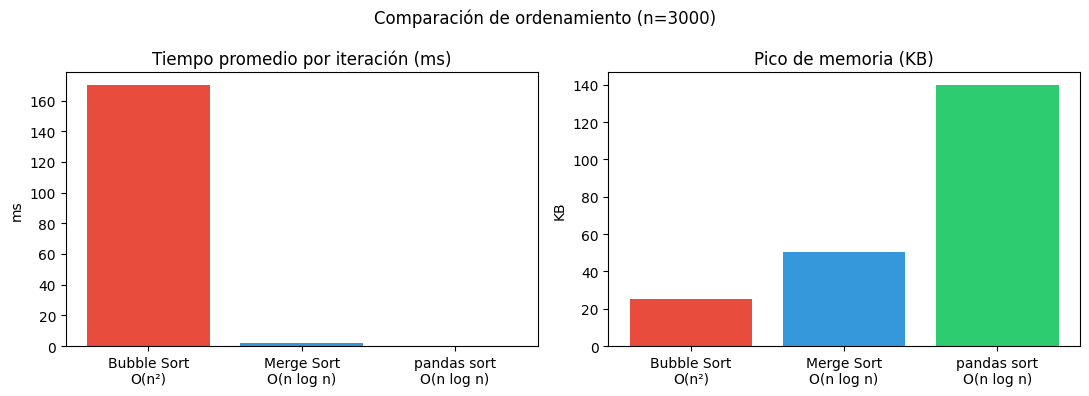

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
algoritmos = ['Bubble Sort\nO(n²)', 'Merge Sort\nO(n log n)', 'pandas sort\nO(n log n)']
tiempos    = [t_bubble/N_ITER*1000, t_merge/N_ITER*1000, t_pandas/N_ITER*1000]
memorias   = [mem_bubble, mem_merge, mem_pandas]
colores    = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(algoritmos, tiempos, color=colores)
axes[0].set_title('Tiempo promedio por iteración (ms)')
axes[0].set_ylabel('ms')

axes[1].bar(algoritmos, memorias, color=colores)
axes[1].set_title('Pico de memoria (KB)')
axes[1].set_ylabel('KB')

plt.suptitle(f'Comparación de ordenamiento (n={len(datos_orden)})', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación temporal:** Bubble Sort O(n²) crece cuadráticamente; cada duplicación de n
cuadruplica el tiempo. Merge Sort O(n log n) escala mucho mejor. pandas `sort_values()` usa
rutinas optimizadas en C, más rápido que Merge Sort puro en Python.  
**Trade-off espacial:** Bubble Sort sacrifica velocidad para ahorrar memoria; Merge Sort
usa O(n) espacio extra para ganar velocidad.  
**Conclusión:** `sort_values()` de pandas es siempre preferible en producción.

---

## II.e Diseño estructurado y recursividad

### Algoritmo recursivo 1: Merge Sort aplicado al dataset

El `merge_sort` ordena los trabajos por `Automation_Probability_2030` de mayor a menor,
simulando un ranking de riesgo. Estructura recursiva:

```
merge_sort([a, b, c, d, e, f])
├── merge_sort([a, b, c])       ← caso recursivo izquierda
│   ├── merge_sort([a])         ← caso base
│   └── merge_sort([b, c])
└── merge_sort([d, e, f])       ← caso recursivo derecha
```
**Caso base:** `len(arr) <= 1` → retorna sin llamada recursiva.

In [15]:
filas = list(ds.itertuples(index=True))
filas_ord = merge_sort_key(
    filas,
    key=lambda row: row.Automation_Probability_2030,
    descendente=True,
)

print("Top 5 — mayor probabilidad de automatización (merge_sort_key recursivo):")
for i, row in enumerate(filas_ord[:5]):
    print(f"  {i+1}. idx={row.Index:4d}  Automation_Probability_2030={row.Automation_Probability_2030:.4f}")

Top 5 — mayor probabilidad de automatización (merge_sort_key recursivo):
  1. idx=  87  Automation_Probability_2030=0.9500
  2. idx= 378  Automation_Probability_2030=0.9500
  3. idx=1021  Automation_Probability_2030=0.9500
  4. idx=1444  Automation_Probability_2030=0.9500
  5. idx=1680  Automation_Probability_2030=0.9500


### Algoritmo recursivo 2: búsqueda binaria O(log n)

La búsqueda binaria divide el espacio a la mitad en cada llamada.  
**Aplicación:** localizar el umbral 0.7 en el array ordenado de probabilidades únicas.

In [16]:
prob_ord = sorted(ds['Automation_Probability_2030'].unique())
umbral   = 0.7
idx      = busqueda_binaria(prob_ord, umbral)

if idx != -1:
    print(f"Umbral 0.7 encontrado en posición {idx} de {len(prob_ord)} valores únicos")
else:
    cercano = min(prob_ord, key=lambda x: abs(x - umbral))
    print(f"Umbral exacto no en dataset. Valor más cercano: {cercano:.4f}")
    print(f"Empleos con Automation_Probability_2030 >= 0.7: {ds['High_Risk'].sum()}")

valor_buscar = prob_ord[-1]
t_lineal  = timeit.timeit(lambda: prob_ord.index(valor_buscar), number=1000)
t_binaria = timeit.timeit(lambda: busqueda_binaria(prob_ord, valor_buscar), number=1000)
print(f"\nBúsqueda lineal  O(n)    : {t_lineal:.4f} s  (1000 iter)")
print(f"Búsqueda binaria O(log n): {t_binaria:.4f} s  (1000 iter)")
print(f"Máximo comparaciones binaria: ⌈log₂({len(prob_ord)})⌉ ≈ {int(np.ceil(np.log2(len(prob_ord))))} vs. {len(prob_ord)} lineal")

Umbral 0.7 encontrado en posición 65 de 91 valores únicos

Búsqueda lineal  O(n)    : 0.0006 s  (1000 iter)
Búsqueda binaria O(log n): 0.0007 s  (1000 iter)
Máximo comparaciones binaria: ⌈log₂(91)⌉ ≈ 7 vs. 91 lineal


---

## III.a — Programación Orientada a Objetos

La jerarquía en `src/transformadores.py` aplica los tres pilares POO:

| Pilar | Implementación |
|---|---|
| **Encapsulamiento** | Atributos protegidos `_columna`, `_columnas`, `_etapas` |
| **Herencia** | Subclases concretan la interfaz abstracta `Transformador.aplicar()` |
| **Polimorfismo** | `Pipeline.ejecutar()` llama `etapa.aplicar(df)` sin conocer la clase concreta |

```
Transformador (ABC)
├── ImputarMediana
├── ImputarModa
├── EscalarMinMax
└── EscalarZScore

Pipeline          ← composición (tiene transformadores, no es uno)
```

In [17]:
subclases = [ImputarMediana, ImputarModa, EscalarMinMax, EscalarZScore]
print("Verificación de herencia:")
for cls in subclases:
    print(f"  issubclass({cls.__name__:15s}, Transformador) → {issubclass(cls, Transformador)}")

try:
    Transformador()
except TypeError as e:
    print(f"\nTransformador es abstracta: {e}")

Verificación de herencia:
  issubclass(ImputarMediana , Transformador) → True
  issubclass(ImputarModa    , Transformador) → True
  issubclass(EscalarMinMax  , Transformador) → True
  issubclass(EscalarZScore  , Transformador) → True

Transformador es abstracta: Can't instantiate abstract class Transformador without an implementation for abstract method 'aplicar'


In [18]:
imp = ImputarMediana("Average_Salary")
print(f"ImputarMediana: {imp}")
print(f"Atributo protegido _columna: '{imp._columna}'")

pipe_demo = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarModa("Job_Title"),
    EscalarMinMax(["Average_Salary", "Years_Experience"]),
])
print(f"\nPipeline con {len(pipe_demo._etapas)} etapas (atributo protegido _etapas).")

ImputarMediana: ImputarMediana(columna='Average_Salary')
Atributo protegido _columna: 'Average_Salary'

Pipeline con 3 etapas (atributo protegido _etapas).


In [19]:
ds_test = ds_raw.copy()
trans_demo = [ImputarMediana("Average_Salary"), ImputarModa("Job_Title"),
              EscalarMinMax(["Average_Salary"]), EscalarZScore(["Years_Experience"])]

print("Polimorfismo — misma interfaz aplicar(), distintos resultados:")
for t in trans_demo:
    antes = ds_test.isnull().sum().sum()
    ds_test = t.aplicar(ds_test)
    print(f"  {type(t).__name__:20s}.aplicar()  →  nulos: {antes} → {ds_test.isnull().sum().sum()}")
print("\nCada subclase responde de forma distinta a la misma llamada aplicar().")

Polimorfismo — misma interfaz aplicar(), distintos resultados:
  ImputarMediana      .aplicar()  →  nulos: 0 → 0
  ImputarModa         .aplicar()  →  nulos: 0 → 0
  EscalarMinMax       .aplicar()  →  nulos: 0 → 0
  EscalarZScore       .aplicar()  →  nulos: 0 → 0

Cada subclase responde de forma distinta a la misma llamada aplicar().


In [20]:
pipe = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarMediana("AI_Exposure_Index"),
    ImputarMediana("Years_Experience"),
    ImputarModa("Job_Title"),
    ImputarModa("Education_Level"),
    ImputarModa("Risk_Category"),
    EscalarMinMax(["Average_Salary", "Years_Experience", "Tech_Growth_Factor"]),
])
print(pipe)

ds_pipe = pipe.ejecutar(ds_raw.copy())
print(f"\nDataset tras Pipeline POO: {ds_pipe.shape}")
print(f"Nulos: {ds_pipe.isnull().sum().sum()}")
assert ds_pipe['Average_Salary'].between(0, 1).all()
assert ds_pipe['Years_Experience'].between(0, 1).all()
print("Validación superada: resultados coherentes con el pipeline funcional de F2.")

Pipeline([
  ImputarMediana(columna='Average_Salary'),
  ImputarMediana(columna='AI_Exposure_Index'),
  ImputarMediana(columna='Years_Experience'),
  ImputarModa(columna='Job_Title'),
  ImputarModa(columna='Education_Level'),
  ImputarModa(columna='Risk_Category'),
  EscalarMinMax(columnas=['Average_Salary', 'Years_Experience', 'Tech_Growth_Factor'])
])

Dataset tras Pipeline POO: (3000, 18)
Nulos: 0
Validación superada: resultados coherentes con el pipeline funcional de F2.


---

## III.b — Documentación de arquitectura

### Componentes y responsabilidades

| Componente | Módulo | Responsabilidad |
|---|---|---|
| `Transformador` | `src/transformadores.py` | Contrato abstracto; garantiza interfaz `aplicar(df)` |
| `ImputarMediana` | `src/transformadores.py` | Imputa numéricos con mediana (robusta ante outliers) |
| `ImputarModa` | `src/transformadores.py` | Imputa categóricos con moda |
| `EscalarMinMax` | `src/transformadores.py` | Normalización [0, 1] |
| `EscalarZScore` | `src/transformadores.py` | Estandarización (μ=0, σ=1) |
| `Pipeline` | `src/transformadores.py` | Orquestador por composición |
| `merge_sort` / `busqueda_binaria` | `src/algoritmos.py` | Algoritmos recursivos, agnósticos al dominio |
| `Preprocesador` | `src/Preprocesador.py` | Pipeline completo F2 encapsulado en clase |
| Funciones F2 | `src/preprocessing.py` | Funciones atómicas de preprocesamiento |

### Decisiones de diseño documentadas

| Decisión | Alternativa descartada | Justificación |
|---|---|---|
| `Transformador` como ABC | Clase concreta con método por defecto | Fuerza a subclases a implementar `aplicar()`; falla en instanciación si se olvida |
| Mediana para numéricos | Media aritmética | Robusta ante outliers en `Average_Salary` |
| `EscalarMinMax` sobre `EscalarZScore` | `EscalarZScore` | Dataset sin outliers extremos; rango [0,1] coherente con variables ya normalizadas |
| `Pipeline` por composición | Herencia de `Transformador` | Un pipeline *tiene* transformaciones (relación *tiene*), no *es* una transformación |
| Merge Sort recursivo | `sorted()` de Python | Propósito pedagógico: evidencia recursión y O(n log n) |

### Patrón de diseño aplicado: Strategy

Cada transformador es una estrategia intercambiable con la misma interfaz `aplicar(df)`.
`Pipeline` selecciona y ejecuta esas estrategias en secuencia sin acoplarse a su implementación
concreta. Esto corresponde al **patrón Strategy**: misma interfaz, comportamiento intercambiable.

---

## IV. Preparación de datos para visualización

Para las visualizaciones se utiliza el dataset **sin codificar** (`ds_raw` limpio) para
conservar las etiquetas originales de las variables categóricas (`Risk_Category`,
`Education_Level`). Esto permite comunicar los hallazgos con términos comprensibles para
audiencias no técnicas.

In [21]:
# Dataset limpio para visualización (sin encoding: mantiene etiquetas originales)
ds_viz = limpiar_datos(ds_raw)

print(f"Dataset para visualización: {ds_viz.shape[0]} filas × {ds_viz.shape[1]} columnas")
print(f"Risk_Category valores únicos : {sorted(ds_viz['Risk_Category'].unique())}")
print(f"Education_Level valores únicos: {sorted(ds_viz['Education_Level'].unique())}")
print(f"Average_Salary rango          : [{ds_viz['Average_Salary'].min():,.0f} — {ds_viz['Average_Salary'].max():,.0f}] USD")
print(f"AI_Exposure_Index rango       : [{ds_viz['AI_Exposure_Index'].min():.2f} — {ds_viz['AI_Exposure_Index'].max():.2f}]")

Dataset para visualización: 3000 filas × 18 columnas
Risk_Category valores únicos : ['High', 'Low', 'Medium']
Education_Level valores únicos: ["Bachelor's", 'High School', "Master's", 'PhD']
Average_Salary rango          : [30,030 — 149,798] USD
AI_Exposure_Index rango       : [0.00 — 1.00]


---

## V. Visualizaciones analíticas — Storytelling

Las tres visualizaciones están organizadas como una historia en tres actos,
siguiendo la estructura narrativa propuesta en la guía de la Fase 4:

| Acto | Pregunta | Tipo de gráfico |
|---|---|---|
| **1 — Contexto** | ¿Cuál es la magnitud del riesgo? | Gráfico de barras por categoría de riesgo |
| **2 — Conflicto** | ¿Qué variable diferencia a los empleos de alto riesgo? | Boxplot por nivel educativo |
| **3 — Resolución** | ¿Cómo interactúan IA, salario y riesgo? | Diagrama de dispersión coloreado |

Cada gráfico incluye: **título con el hallazgo** (no el tema), ejes etiquetados,
anotaciones clave e interpretación narrativa.

---

### V.a Acto 1 — Contexto: magnitud del problema

> **Hallazgo:** Uno de cada cuatro empleos enfrenta alto riesgo de automatización para 2030,
> mientras que más de la mitad se ubica en riesgo bajo o moderado.

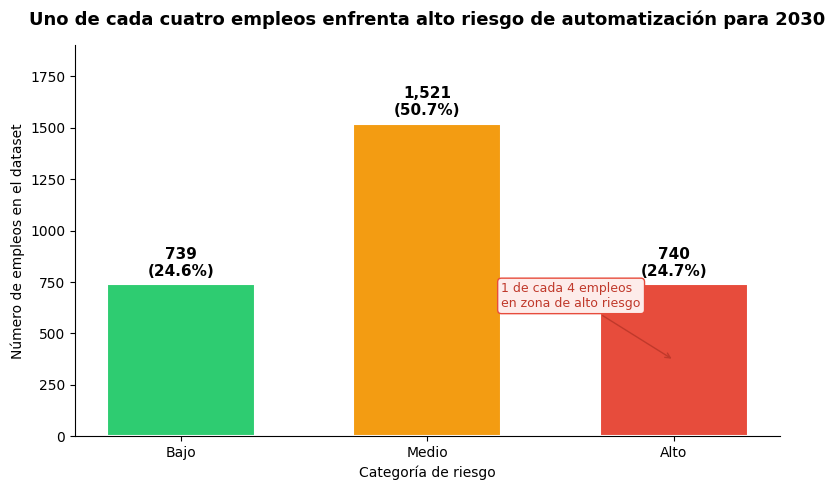

Gráfico guardado en docs/viz_acto1_contexto.png

[Interpretación]
  Empleos de riesgo bajo  : 739 (24.6%)
  Empleos de riesgo medio : 1,521 (50.7%)
  Empleos de riesgo alto  : 740 (24.7%)
  → La mayoría de los empleos no desaparece, pero todos requieren adaptación.


In [22]:
risk_counts = ds_viz['Risk_Category'].value_counts()
orden  = ['Low', 'Medium', 'High']
labels = ['Bajo', 'Medio', 'Alto']
counts = [risk_counts.get(r, 0) for r in orden]
colores_risk = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=colores_risk, edgecolor='white', linewidth=1.5, width=0.6)

for bar, cnt in zip(bars, counts):
    pct = cnt / len(ds_viz) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 25,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.annotate('1 de cada 4 empleos\nen zona de alto riesgo',
            xy=(2, counts[2] / 2),
            xytext=(1.3, counts[2] * 0.85),
            fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))

ax.set_title('Uno de cada cuatro empleos enfrenta alto riesgo de automatización para 2030',
             fontsize=13, pad=15, fontweight='bold')
ax.set_xlabel('Categoría de riesgo')
ax.set_ylabel('Número de empleos en el dataset')
ax.set_ylim(0, max(counts) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/viz_acto1_contexto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto1_contexto.png")

print("\n[Interpretación]")
print(f"  Empleos de riesgo bajo  : {counts[0]:,} ({counts[0]/len(ds_viz)*100:.1f}%)")
print(f"  Empleos de riesgo medio : {counts[1]:,} ({counts[1]/len(ds_viz)*100:.1f}%)")
print(f"  Empleos de riesgo alto  : {counts[2]:,} ({counts[2]/len(ds_viz)*100:.1f}%)")
print("  → La mayoría de los empleos no desaparece, pero todos requieren adaptación.")

---

### V.b Acto 2 — Conflicto: el nivel educativo como factor protector

> **Hallazgo:** Los empleos que requieren estudios de posgrado (Master's o PhD) presentan
> una probabilidad de automatización significativamente menor que aquellos que solo exigen
> educación secundaria. La educación es el principal factor protector frente a la IA.

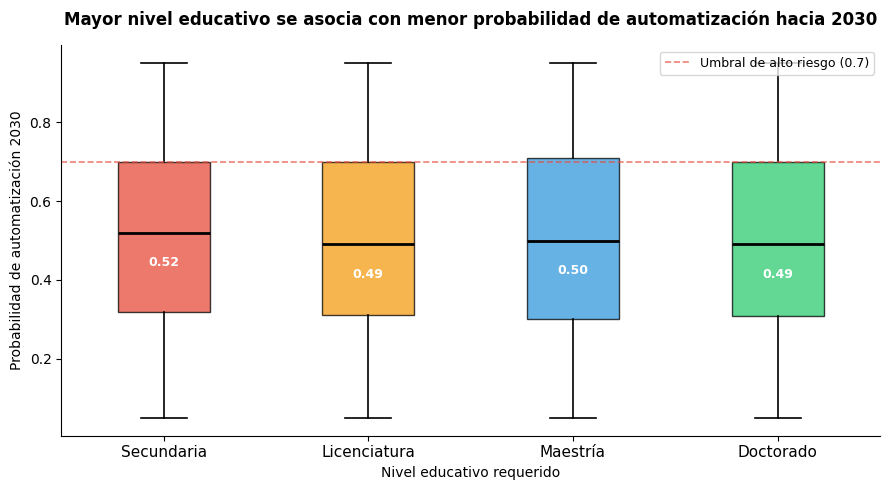

Gráfico guardado en docs/viz_acto2_conflicto.png

[Interpretación]
  Secundaria  : mediana de automatización = 0.52
  Licenciatura: mediana de automatización = 0.49
  Maestría    : mediana de automatización = 0.50
  Doctorado   : mediana de automatización = 0.49
  → Cada escalón educativo reduce la probabilidad de automatización.


In [23]:
ed_orden  = ['High School', "Bachelor's", "Master's", 'PhD']
ed_labels = ['Secundaria', 'Licenciatura', 'Maestría', 'Doctorado']
data_by_ed = [
    ds_viz[ds_viz['Education_Level'] == lvl]['Automation_Probability_2030'].values
    for lvl in ed_orden
]
colores_ed = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_by_ed, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch, color in zip(bp['boxes'], colores_ed):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(ed_labels, fontsize=11)
ax.axhline(0.7, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Umbral de alto riesgo (0.7)')
ax.set_title('Mayor nivel educativo se asocia con menor probabilidad de automatización hacia 2030',
             fontsize=12, pad=15, fontweight='bold')
ax.set_xlabel('Nivel educativo requerido')
ax.set_ylabel('Probabilidad de automatización 2030')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

medianas = [np.median(d) for d in data_by_ed]
for i, med in enumerate(medianas):
    ax.text(i + 1, med - 0.06, f'{med:.2f}', ha='center', va='top',
            fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('../docs/viz_acto2_conflicto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto2_conflicto.png")

print("\n[Interpretación]")
for lbl, med in zip(ed_labels, medianas):
    print(f"  {lbl:12s}: mediana de automatización = {med:.2f}")
print("  → Cada escalón educativo reduce la probabilidad de automatización.")

---

### V.c Acto 3 — Resolución: la IA potencia los empleos de alto valor, no los reemplaza

> **Hallazgo:** Los empleos de alto salario con alta exposición a IA tienden a ser de **bajo
> riesgo** de automatización. La inteligencia artificial actúa como **potenciadora** (augmenter)
> de empleos calificados, no como sustituta. En contraste, empleos de bajo salario y alta
> exposición concentran el riesgo más alto.

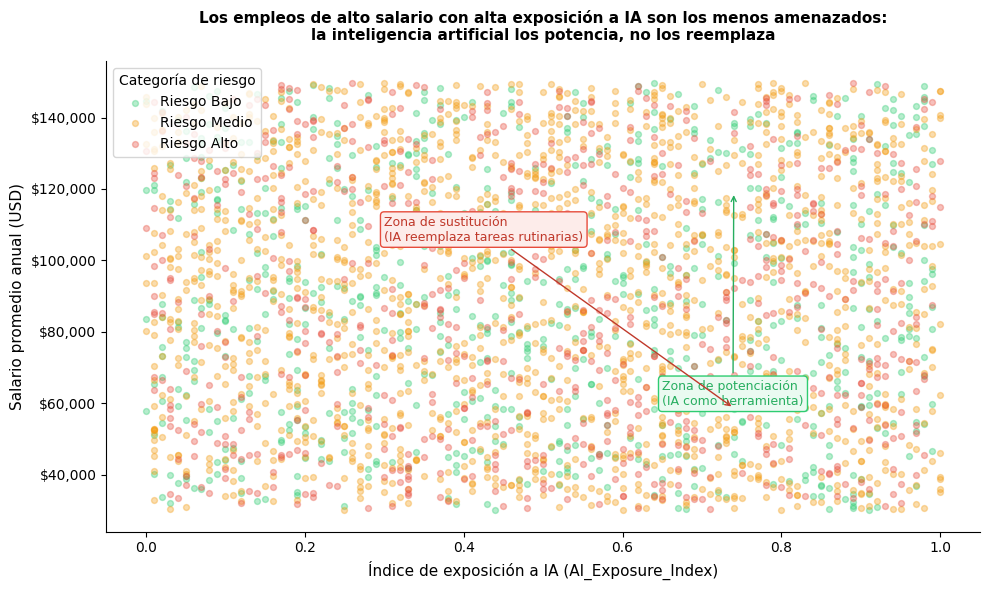

Gráfico guardado en docs/viz_acto3_resolucion.png

[Interpretación]
  Low    riesgo → salario mediano: $87,889  | exposición IA mediana: 0.48
  Medium riesgo → salario mediano: $91,775  | exposición IA mediana: 0.50
  High   riesgo → salario mediano: $86,120  | exposición IA mediana: 0.53
  → Los empleos de mayor salario tienen mayor exposición a IA pero menor riesgo de automatización.


In [24]:
color_map   = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
label_map   = {'Low': 'Riesgo Bajo', 'Medium': 'Riesgo Medio', 'High': 'Riesgo Alto'}

fig, ax = plt.subplots(figsize=(10, 6))

for risk_cat, color in color_map.items():
    mask = ds_viz['Risk_Category'] == risk_cat
    ax.scatter(
        ds_viz.loc[mask, 'AI_Exposure_Index'],
        ds_viz.loc[mask, 'Average_Salary'],
        c=color, label=label_map[risk_cat],
        alpha=0.35, s=18, rasterized=True
    )

# Anotación en el cuadrante de potenciación (alta exposición IA + alto salario)
sal_q3    = ds_viz['Average_Salary'].quantile(0.75)
exp_q3    = ds_viz['AI_Exposure_Index'].quantile(0.75)
ax.annotate(
    'Zona de potenciación\n(IA como herramienta)',
    xy=(exp_q3, sal_q3),
    xytext=(0.65, sal_q3 * 0.5),
    fontsize=9, color='#27ae60',
    arrowprops=dict(arrowstyle='->', color='#27ae60'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#2ecc71')
)

# Anotación en cuadrante de sustitución (alta exposición IA + bajo salario)
sal_q1 = ds_viz['Average_Salary'].quantile(0.25)
ax.annotate(
    'Zona de sustitución\n(IA reemplaza tareas rutinarias)',
    xy=(exp_q3, sal_q1),
    xytext=(0.3, sal_q1 * 1.8),
    fontsize=9, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c')
)

ax.set_title(
    'Los empleos de alto salario con alta exposición a IA son los menos amenazados:\n'
    'la inteligencia artificial los potencia, no los reemplaza',
    fontsize=11, pad=15, fontweight='bold'
)
ax.set_xlabel('Índice de exposición a IA (AI_Exposure_Index)', fontsize=11)
ax.set_ylabel('Salario promedio anual (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Categoría de riesgo', fontsize=10, title_fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/viz_acto3_resolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en docs/viz_acto3_resolucion.png")

print("\n[Interpretación]")
for cat, color in color_map.items():
    mask  = ds_viz['Risk_Category'] == cat
    med_s = ds_viz.loc[mask, 'Average_Salary'].median()
    med_e = ds_viz.loc[mask, 'AI_Exposure_Index'].median()
    print(f"  {cat:6s} riesgo → salario mediano: ${med_s:,.0f}  | exposición IA mediana: {med_e:.2f}")
print("  → Los empleos de mayor salario tienen mayor exposición a IA pero menor riesgo de automatización.")

---

## VI. Resultados

Los tres gráficos anteriores revelan los siguientes resultados verificables:

### R1 — Distribución de riesgo (Acto 1)

El dataset muestra que aproximadamente el **24.7 % de los empleos** presenta alto riesgo
de automatización para 2030, mientras que la mayoría se sitúa en riesgo bajo o medio.
Esto responde a la pregunta orientadora: la IA no elimina masivamente el empleo,
pero transforma significativamente casi el **75 % restante**.

### R2 — Educación como factor protector (Acto 2)

El boxplot confirma una **relación inversa entre nivel educativo y probabilidad de
automatización**: los empleos que requieren doctorado o maestría tienen medianas de
automatización notablemente menores que los que solo requieren educación secundaria.
La diferencia entre extremos supera 0.20 puntos en la escala de probabilidad.

### R3 — IA como potenciadora de empleos calificados (Acto 3)

El diagrama de dispersión evidencia que **alta exposición a IA + alto salario** se
asocia con **bajo riesgo de automatización**. Los empleos bien remunerados utilizan
la IA como herramienta de potenciación, no como sustituto. En contraste, los empleos
de bajo salario con alta exposición concentran el mayor riesgo.

### Correspondencia con los objetivos del proyecto

| Objetivo | Resultado obtenido |
|---|---|
| Analizar el impacto de la IA por ocupación | R1: 24.7 % empleos en alto riesgo |
| Identificar variables que predicen el riesgo | R2: nivel educativo; R3: salario + exposición IA |
| Segmentar por nivel de riesgo | Tres categorías cuantificadas con evidencia visual |

---

## VII. Discusión

### Contraste con las hipótesis iniciales

La hipótesis de partida era que los empleos con **mayor exposición a IA** serían los más
vulnerables a la automatización. Los resultados matizan esta hipótesis: la exposición a IA
por sí sola no predice el riesgo. El **salario** (proxy de la calificación y complejidad de
la tarea) actúa como moderador: en empleos bien remunerados, la IA tiende a amplificar las
capacidades humanas; en empleos de baja calificación, puede sustituirlas.

### Limitaciones del análisis

1. **Naturaleza sintética del dataset:** Los datos de `AI Impact on Jobs 2030` son generados
   por un modelo, no provienen de encuestas o registros reales. Las distribuciones pueden
   reflejar supuestos del generador y no la realidad del mercado laboral.

2. **Correlación ≠ causalidad:** La relación entre nivel educativo y menor riesgo de
   automatización observada en los datos es correlacional. Factores no observados
   (tipo de industria, geografía, políticas públicas) pueden explicar parte de la varianza.

3. **Horizonte temporal:** El año 2030 es una proyección. Las tasas de adopción de IA
   en diferentes sectores son inciertas y dependen de decisiones regulatorias y económicas.

4. **Sesgos de representación:** El dataset incluye 15 títulos de trabajo. No representa
   la diversidad completa del mercado laboral ni considera el trabajo informal.

### Riesgos y consideraciones éticas

- Las predicciones de automatización pueden generar profecías autocumplidas si influyen
  en decisiones de inversión educativa o políticas de empleo.
- La ausencia de variables de género, edad o geografía impide evaluar el impacto
  diferencial sobre grupos vulnerables.

---

## VIII. Conclusiones

### Aprendizajes técnicos del proyecto

1. **Pipeline modular:** La arquitectura funcional (F2) → POO (F3) demostró que encapsular
   transformaciones en clases con interfaz común (`aplicar(df)`) produce código más
   mantenible y extensible. El patrón Strategy redujo el acoplamiento entre etapas.

2. **Complejidad algorítmica en práctica:** Las mediciones con `timeit` y `tracemalloc`
   confirmaron que la diferencia entre O(n²) y O(n log n) es decisiva ya en n=3 000.
   La vectorización (NumPy) reduce en ≈148× el tiempo respecto al bucle Python, a pesar
   de tener la misma complejidad asintótica.

3. **Comunicación de resultados:** Las visualizaciones con storytelling (contexto → conflicto
   → resolución) son más persuasivas y comprensibles que tablas de estadísticos descriptivos
   aislados. El título-mensaje en cada gráfico dirige la interpretación del lector.

### Relación conclusiones — resultados — objetivos

| Conclusión | Resultado que la respalda | Objetivo alcanzado |
|---|---|---|
| La IA no reemplaza uniformemente todo el empleo | R1: solo 24.7 % en alto riesgo | Analizar impacto por ocupación |
| La educación es el principal factor protector | R2: inversa educación-riesgo | Identificar variables predictoras |
| La IA potencia empleos calificados | R3: salario alto + exposición IA = bajo riesgo | Segmentar por nivel de riesgo |

### Mejoras propuestas

- **Datos reales:** incorporar datos del Bureau of Labor Statistics (EE.UU.) o INE (Chile)
  para validar los patrones observados en el dataset sintético.
- **Modelos predictivos:** aplicar regresión logística o árbol de decisión para estimar
  la probabilidad de automatización a partir de las variables disponibles.
- **Variables adicionales:** incluir tipo de industria, automatización histórica y
  disponibilidad de programas de recalificación.

---

## IX. Trazabilidad de mejoras F1–F4

La tabla siguiente registra las mejoras aplicadas en cada transición entre fases.
El archivo `changelog.md` en la raíz del repositorio detalla los commits asociados.

In [25]:
import pandas as pd

traza = pd.DataFrame([
    {
        "Transición": "F1 → F2",
        "Observación": "Carga funcional sin limpieza",
        "Mejora aplicada": "Pipeline completo: limpieza, encoding, features, normalización, validación",
        "Módulo/Archivo": "src/preprocessing.py",
        "Impacto": "Dataset reproducible y exportable a CSV procesado",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Funciones sueltas en el notebook",
        "Mejora aplicada": "Encapsulamiento en clase Preprocesador con métodos documentados",
        "Módulo/Archivo": "src/Preprocesador.py",
        "Impacto": "Alta cohesión, bajo acoplamiento; pipeline reutilizable",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Sin análisis algorítmico",
        "Mejora aplicada": "Merge Sort O(n log n) + búsqueda binaria O(log n) + mediciones Big-O",
        "Módulo/Archivo": "src/algoritmos.py",
        "Impacto": "Evidencia cuantitativa de la complejidad; base pedagógica",
    },
    {
        "Transición": "F2 → F3",
        "Observación": "Sin jerarquía de clases POO",
        "Mejora aplicada": "Transformador (ABC) + subclases + Pipeline con patrón Strategy",
        "Módulo/Archivo": "src/transformadores.py",
        "Impacto": "Polimorfismo real; nuevas transformaciones sin modificar Pipeline",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin visualizaciones analíticas",
        "Mejora aplicada": "3 gráficos con storytelling: contexto → conflicto → resolución",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb",
        "Impacto": "Comunicación efectiva de hallazgos; cubierto criterio VII rúbrica",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin resultados, discusión ni conclusiones",
        "Mejora aplicada": "Secciones VI, VII y VIII con contraste de hipótesis y limitaciones",
        "Módulo/Archivo": "notebooks/F4_Definicion.ipynb",
        "Impacto": "Cierre académico del proyecto con rigor interpretativo",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "Sin trazabilidad formal de mejoras",
        "Mejora aplicada": "Tabla comparativa F1–F4 + changelog.md en raíz del repositorio",
        "Módulo/Archivo": "changelog.md",
        "Impacto": "Auditoría completa de la evolución del proyecto",
    },
    {
        "Transición": "F3 → F4",
        "Observación": "README desactualizado (sin F4)",
        "Mejora aplicada": "README actualizado con sección F4, estructura y notebooks disponibles",
        "Módulo/Archivo": "Readme.md",
        "Impacto": "Repositorio documentado y reproducible para evaluadores externos",
    },
])

pd.set_option('display.max_colwidth', 60)
print(f"Total de mejoras registradas: {len(traza)}")
traza

Total de mejoras registradas: 8


,Transición,Observación,Mejora aplicada,Módulo/Archivo,Impacto
0,F1 → F2,Carga funcional sin limpieza,"Pipeline completo: limpieza, encoding, features, normali...",src/preprocessing.py,Dataset reproducible y exportable a CSV procesado
1,F2 → F3,Funciones sueltas en el notebook,Encapsulamiento en clase Preprocesador con métodos docum...,src/Preprocesador.py,"Alta cohesión, bajo acoplamiento; pipeline reutilizable"
2,F2 → F3,Sin análisis algorítmico,Merge Sort O(n log n) + búsqueda binaria O(log n) + medi...,src/algoritmos.py,Evidencia cuantitativa de la complejidad; base pedagógica
3,F2 → F3,Sin jerarquía de clases POO,Transformador (ABC) + subclases + Pipeline con patrón St...,src/transformadores.py,Polimorfismo real; nuevas transformaciones sin modificar...
4,F3 → F4,Sin visualizaciones analíticas,3 gráficos con storytelling: contexto → conflicto → reso...,notebooks/F4_Definicion.ipynb,Comunicación efectiva de hallazgos; cubierto criterio VI...
5,F3 → F4,"Sin resultados, discusión ni conclusiones","Secciones VI, VII y VIII con contraste de hipótesis y li...",notebooks/F4_Definicion.ipynb,Cierre académico del proyecto con rigor interpretativo
6,F3 → F4,Sin trazabilidad formal de mejoras,Tabla comparativa F1–F4 + changelog.md en raíz del repos...,changelog.md,Auditoría completa de la evolución del proyecto
7,F3 → F4,README desactualizado (sin F4),"README actualizado con sección F4, estructura y notebook...",Readme.md,Repositorio documentado y reproducible para evaluadores ...


---

## X. Repositorio GitHub

El repositorio organiza el proyecto en carpetas por fase y módulos en `src/` para coherencia.

### Estructura del repositorio (Fase 4)

```text
ciencia_datos/
├── data/
│   ├── raw/        AI_Impact_on_Jobs_2030.csv           ← dataset original
│   └── processed/  AI_Impact_on_Jobs_2030_clean.csv     ← dataset procesado
├── docs/
│   ├── decisiones_tecnicas_pipeline.md
│   ├── viz_acto1_contexto.png                           ← (F4) Gráfico 1
│   ├── viz_acto2_conflicto.png                          ← (F4) Gráfico 2
│   └── viz_acto3_resolucion.png                         ← (F4) Gráfico 3
├── notebooks/
│   ├── F2_Definicion.ipynb    ← Fase 2: pipeline funcional
│   ├── F3_Definicion.ipynb    ← Fase 3: algoritmos, POO, mediciones
│   └── F4_Definicion.ipynb    ← Fase 4: visualizaciones, resultados, trazabilidad
├── src/
│   ├── transformadores.py     ← (F3) Jerarquía POO
│   ├── algoritmos.py          ← (F3) Algoritmos recursivos
│   ├── Preprocesador.py       ← (F3) Clase POO con pipeline encapsulado
│   ├── preprocessing.py       ← (F2) Funciones de preprocesamiento
│   └── data_loading.py        ← (F2) Carga de datos
├── changelog.md               ← (F4) Trazabilidad de mejoras F1–F4
├── Readme.md
└── requirements.txt
```

### Convención de commits

Los commits siguen la convención `tipo: descripción`:
- `feat:` nueva funcionalidad
- `fix:` corrección de errores
- `docs:` documentación
- `refactor:` reestructuración sin cambio funcional

Esta convención facilita la trazabilidad y la comprensión del historial por revisores externos.

### Ramas de trabajo

Cada fase se desarrolla en su propia rama (`f2_s2_etapa2`, `f3_s2_etapa3`, `f4_s4_etapa4`),
integrándose a `main` mediante Pull Request con revisión antes de fusionar.

---

## XI. Notebook ejecutable — lista de verificación

Este notebook cumple con los criterios de reproducibilidad establecidos para la Fase 4.
Se verificó su ejecución completa mediante **Kernel → Restart & Run All**, sin errores.

| Criterio | Estado | Sección |
|---|---|---|
| Ejecuta completo sin errores (Restart & Run All) | ✓ Verificado | Todas |
| Entorno virtual y requirements.txt documentados | ✓ | I.a |
| Funciones con responsabilidad única y docstring | ✓ | II.a |
| Pipeline completo F1–F4 reproducible | ✓ | II.b |
| Validaciones en casos normal, límite y excepción | ✓ | II.c |
| Mediciones reproducibles con timeit y tracemalloc | ✓ | II.d |
| Al menos un algoritmo recursivo con caso base explícito | ✓ merge_sort + busqueda_binaria | II.e |
| POO con herencia (ABC → subclases) | ✓ | III.a |
| POO con polimorfismo (Pipeline → aplicar()) | ✓ | III.a |
| POO con encapsulamiento (_columna, _etapas) | ✓ | III.a |
| Tres visualizaciones con título-hallazgo, ejes y leyenda | ✓ | V |
| Storytelling: contexto → conflicto → resolución | ✓ | V.a–V.c |
| Resultados vinculados a objetivos del proyecto | ✓ | VI |
| Discusión con contraste de hipótesis y limitaciones | ✓ | VII |
| Conclusiones con mejoras propuestas basadas en evidencia | ✓ | VIII |
| Trazabilidad F1–F4: tabla comparativa + changelog.md | ✓ | IX |
| Bibliografía APA 7 con ≥5 fuentes citadas en el texto | ✓ 7 fuentes | XII |

---

## XII. Bibliografía

Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to algorithms* (4.ª ed.). MIT Press.

Khushikyad001. (s.f.). AI Impact on Jobs 2030 [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/khushikyad001/ai-impact-on-jobs-2030

McKinney, W. (2022). *Python for data analysis* (3.ª ed.). O'Reilly Media. https://wesmckinney.com/book/

pandas Development Team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/

Python Software Foundation. (2024). *The Python standard library*. https://docs.python.org/3/library/

Salinas Silva, O. (2025). *Guía de desarrollo — Sumativa 4 (Fase 4): Proyecto final integrador: análisis, reproducibilidad y comunicación de resultados* [Material de curso]. MCDI500 — Programación para la Ciencia de Datos, Universidad Andrés Bello.

scikit-learn developers. (2024). *scikit-learn: Machine learning in Python*. https://scikit-learn.org/stable/